# 타이타닉호 생존 데이터 분석

인터넷에서 타이타닉호 승객 데이터를 내려받아 pandas로 데이터 클랜징과 다각도 분석을 수행하고, matplotlib으로 시각화합니다.

## 분석 순서

1. 데이터 수집 및 구조 확인
2. 결측치, 중복, 자료형 클랜징
3. 생존율과 주요 변수의 관계 분석
4. 성별 생존율 막대그래프 작성

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'AppleGothic'
except Exception:
    pass

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [2]:
# seaborn에서 관리하는 Titanic CSV를 인터넷에서 직접 내려받습니다.
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(url)

print(f'행 수: {df.shape[0]:,}, 열 수: {df.shape[1]}')
display(df.head())

행 수: 891, 열 수: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


## 1. 데이터 구조와 품질 확인

In [3]:
# 컬럼별 자료형, 결측치 개수, 중복 행을 함께 확인합니다.
quality = pd.DataFrame({
    '자료형': df.dtypes.astype(str),
    '결측치수': df.isna().sum(),
    '결측치비율(%)': df.isna().mean().mul(100).round(2),
    '고유값수': df.nunique()
})
display(quality)
print(f'중복 행 수: {df.duplicated().sum():,}')

,자료형,결측치수,결측치비율(%),고유값수
survived,int64,0,0.00,2
pclass,int64,0,0.00,3
sex,str,0,0.00,2
age,float64,177,19.87,88
sibsp,int64,0,0.00,7
parch,int64,0,0.00,7
fare,float64,0,0.00,248
embarked,str,2,0.22,3
class,str,0,0.00,3
who,str,0,0.00,3


중복 행 수: 107


## 2. 데이터 클랜징

- 분석에 필요한 컬럼만 사용합니다.
- 중복 행을 제거합니다.
- `age`는 성별과 객실 등급별 중앙값으로 결측치를 보완합니다.
- `embarked`와 `embark_town`은 최빈값으로 보완합니다.
- 분석에 편리하도록 범주형 라벨과 연령대 컬럼을 추가합니다.

In [4]:
columns = [
    'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
    'fare', 'embarked', 'class', 'who', 'alone', 'embark_town'
]
clean_df = df[columns].copy()
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

clean_df['age'] = clean_df.groupby(['sex', 'pclass'])['age'].transform(
    lambda values: values.fillna(values.median())
)
clean_df['age'] = clean_df['age'].fillna(clean_df['age'].median())
clean_df['embarked'] = clean_df['embarked'].fillna(clean_df['embarked'].mode()[0])
clean_df['embark_town'] = clean_df['embark_town'].fillna(clean_df['embark_town'].mode()[0])

clean_df['survived_label'] = clean_df['survived'].map({0: '사망', 1: '생존'})
clean_df['sex_label'] = clean_df['sex'].map({'male': '남성', 'female': '여성'})
clean_df['age_group'] = pd.cut(
    clean_df['age'],
    bins=[0, 12, 19, 39, 59, np.inf],
    labels=['아동', '청소년', '성인', '중년', '노년'],
    right=True
)

print(f'클랜징 후 행 수: {len(clean_df):,}')
display(clean_df.isna().sum().to_frame('남은 결측치'))
display(clean_df.head())

클랜징 후 행 수: 780


,남은 결측치
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone,embark_town,survived_label,sex_label,age_group
0,0,3,male,22.00,1,0,7.25,S,Third,man,False,Southampton,사망,남성,성인
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,Cherbourg,생존,여성,성인
2,1,3,female,26.00,0,0,7.92,S,Third,woman,True,Southampton,생존,여성,성인
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,Southampton,생존,여성,성인
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,Southampton,사망,남성,성인


## 3. 기본 통계와 전체 생존율

In [5]:
summary = clean_df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].describe().T
display(summary)
print(f"전체 생존율: {clean_df['survived'].mean() * 100:.2f}%")

,count,mean,std,min,25%,50%,75%,max
survived,780.00,0.41,0.49,0.00,0.00,0.00,1.00,1.00
pclass,780.00,2.25,0.85,1.00,1.00,3.00,3.00,3.00
age,780.00,29.59,13.93,0.42,21.75,28.00,38.00,80.00
sibsp,780.00,0.53,0.99,0.00,0.00,0.00,1.00,8.00
parch,780.00,0.42,0.84,0.00,0.00,0.00,1.00,6.00
fare,780.00,34.83,52.26,0.00,8.05,15.95,34.38,512.33


전체 생존율: 41.28%


## 4. 성별 생존율 분석

성별별 승객 수와 생존율을 계산하고, 요청한 비교 막대그래프로 표현합니다.

,승객수,생존자수,생존율(%)
sex_label,,,
여성,292,216,73.97
남성,488,106,21.72


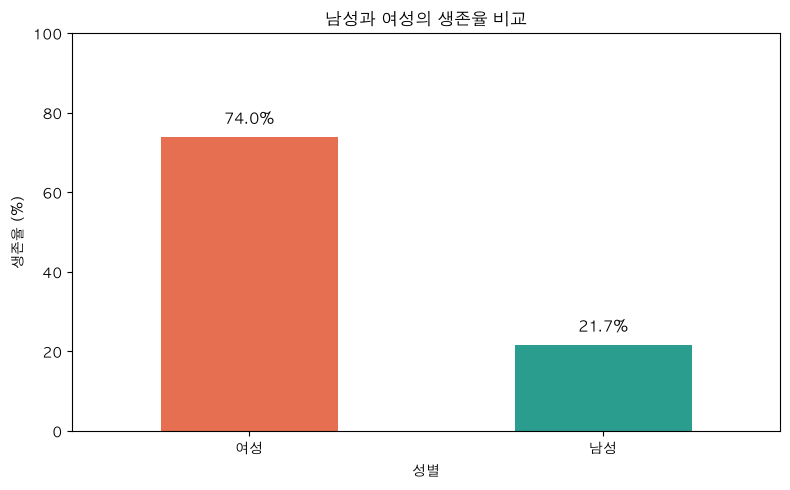

In [6]:
gender_summary = (
    clean_df.groupby('sex_label', observed=True)['survived']
    .agg(승객수='count', 생존자수='sum', 생존율='mean')
    .sort_values('생존율', ascending=False)
)
gender_summary['생존율(%)'] = gender_summary['생존율'] * 100
display(gender_summary[['승객수', '생존자수', '생존율(%)']])

ax = gender_summary['생존율(%)'].plot(
    kind='bar',
    figsize=(8, 5),
    color=['#e76f51', '#2a9d8f'],
    rot=0
)
ax.set_title('남성과 여성의 생존율 비교')
ax.set_xlabel('성별')
ax.set_ylabel('생존율 (%)')
ax.set_ylim(0, 100)
for bar, value in zip(ax.patches, gender_summary['생존율(%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f'{value:.1f}%',
            ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 5. 객실 등급별 분석

,승객수,생존율(%)
class,,
First,212,63.68
Second,164,50.61
Third,404,25.74


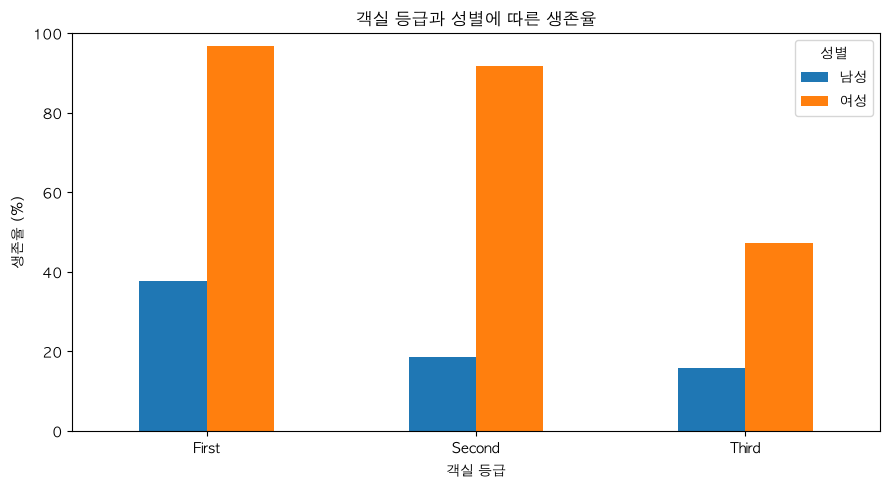

In [7]:
class_summary = (
    clean_df.groupby('class', observed=True)['survived']
    .agg(승객수='count', 생존율='mean')
)
class_summary['생존율(%)'] = class_summary['생존율'] * 100
display(class_summary[['승객수', '생존율(%)']])

class_gender_rate = pd.pivot_table(
    clean_df, index='class', columns='sex_label', values='survived', aggfunc='mean'
) * 100
class_gender_rate.plot(kind='bar', figsize=(9, 5), rot=0)
plt.title('객실 등급과 성별에 따른 생존율')
plt.xlabel('객실 등급')
plt.ylabel('생존율 (%)')
plt.ylim(0, 100)
plt.legend(title='성별')
plt.tight_layout()
plt.show()

## 6. 연령대와 승선 항구별 분석

,승객수,생존율(%)
age_group,,
아동,68,57.35
청소년,90,43.33
성인,443,40.41
중년,154,37.66
노년,25,28.00


,승객수,생존율(%)
embark_town,,
Cherbourg,155,58.06
Queenstown,58,34.48
Southampton,567,37.39


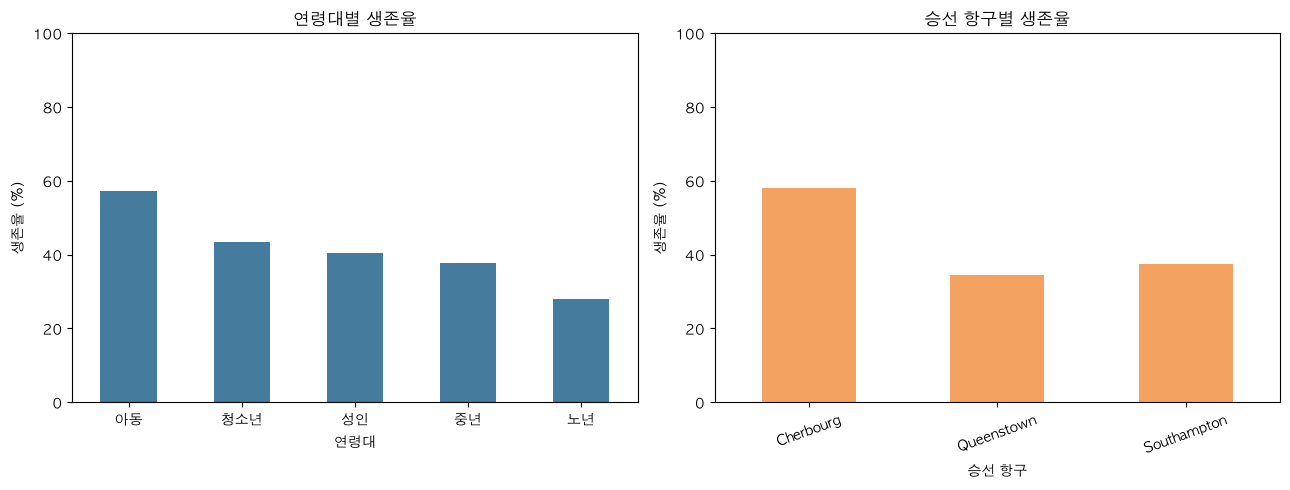

In [8]:
age_summary = (
    clean_df.groupby('age_group', observed=True)['survived']
    .agg(승객수='count', 생존율='mean')
)
age_summary['생존율(%)'] = age_summary['생존율'] * 100
display(age_summary[['승객수', '생존율(%)']])

embark_summary = (
    clean_df.groupby('embark_town', observed=True)['survived']
    .agg(승객수='count', 생존율='mean')
)
embark_summary['생존율(%)'] = embark_summary['생존율'] * 100
display(embark_summary[['승객수', '생존율(%)']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
age_summary['생존율(%)'].plot(kind='bar', ax=axes[0], color='#457b9d', rot=0)
axes[0].set_title('연령대별 생존율')
axes[0].set_xlabel('연령대')
axes[0].set_ylabel('생존율 (%)')
axes[0].set_ylim(0, 100)

embark_summary['생존율(%)'].plot(kind='bar', ax=axes[1], color='#f4a261', rot=20)
axes[1].set_title('승선 항구별 생존율')
axes[1].set_xlabel('승선 항구')
axes[1].set_ylabel('생존율 (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 분석 요약

성별, 객실 등급, 연령대, 승선 항구별 생존율 표를 통해 생존 여부와 여러 변수의 관계를 비교할 수 있습니다. 특히 성별 생존율 막대그래프에서 남성과 여성 사이의 차이를 확인할 수 있습니다. 이 데이터는 역사적 승객 기록의 표본이므로 결과를 일반적인 재난 상황의 인과관계로 해석하지 않고, 관측된 데이터의 패턴으로 해석해야 합니다.